# Decision Tree Classification – Heart Disease Dataset

- Data preparation
- Exploratory Data Analysis (EDA)
- Missing-value, outlier and inconsistency checks
- Feature visualization and correlation analysis
- Feature engineering where necessary
- Train/test split
- Decision Tree classification
- Accuracy, precision, recall, F1-score and ROC-AUC
- Hyperparameter tuning
- Decision-tree visualization
- Feature importance
- Analysis of model performance
- Answers to the interview questions

# Note

The workbook's **Description** sheet defines `num` as:

0 = no heart disease; 1,2,3,4 = stages of heart disease

I keep the original five-class target (0, 1, 2, 3, 4) rather than changing it into a binary target. This is a multiclass classification problem based on the supplied data dictionary.


## 1. Load the dataset


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

# Load both sheets
description = pd.read_excel("/content/heart_disease.xlsx", sheet_name="Description", header=None)
df = pd.read_excel("/content/heart_disease.xlsx", sheet_name="Heart_disease")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (908, 13)


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


## 2. Understand the variables

The supplied data dictionary describes the main variables:

- `age` – age in years
- `sex` – gender
- `cp` – chest pain type
- `trestbps` – resting blood pressure
- `chol` – cholesterol measure
- `fbs` – fasting blood sugar > 120 mg/dl
- `restecg` – resting ECG observation
- `thalch` – maximum heart rate achieved
- `exang` – exercise-induced angina
- `oldpeak` – ST depression induced by exercise relative to rest
- `slope` – slope of the peak exercise ST segment
- `thal` – thal
- `num` – target, where 0 is no heart disease and 1–4 are stages of heart disease




In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

print("\nSummary statistics:")
display(df.describe(include="all").T)


Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'thal', 'num']

Data types:


,Data Type
age,int64
sex,object
cp,object
trestbps,int64
chol,int64
fbs,bool
restecg,object
thalch,int64
exang,object
oldpeak,float64



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,908.0,NaN,NaN,NaN,53.79185,9.158031,29.0,47.75,54.0,60.0,77.0
sex,908,2,Male,718,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,908,4,asymptomatic,495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,908.0,NaN,NaN,NaN,133.430617,20.401608,0.0,120.0,130.0,144.0,200.0
chol,908.0,NaN,NaN,NaN,201.484581,112.097949,0.0,176.75,224.0,270.0,603.0
fbs,908,2,False,723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,908,3,normal,542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,908.0,NaN,NaN,NaN,135.957048,26.804929,60.0,118.0,138.0,156.0,202.0
exang,908,4,False,516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
oldpeak,846.0,NaN,NaN,NaN,0.891253,1.093875,-2.6,0.0,0.5,1.5,6.2


## 3. Missing values

The EDA requirement asks me to check missing values.

The supplied dataset contains missing values in oldpeak. I will handle these later using median imputation, because `oldpeak` is numerical and the median is less affected by extreme observations than the mean,
No target values are missing.


In [5]:
missing = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)

display(missing)

print("Duplicate rows:", df.duplicated().sum())


,Missing Count,Missing Percentage
oldpeak,62,6.83
sex,0,0.00
cp,0,0.00
trestbps,0,0.00
age,0,0.00
chol,0,0.00
fbs,0,0.00
thalch,0,0.00
restecg,0,0.00
exang,0,0.00


Duplicate rows: 1


## 4. Check inconsistencies in categorical values

One inconsistency is visible in `exang`: the dataset contains `False`, `True`, and also string values `FALSE` and `TURE`.

`TURE` appears to be an inconsistent spelling of `True`. Since this is clearly a categorical representation issue, I standardize the values before modelling.
I do not change any other category based only on assumptions.


In [6]:
for col in df.select_dtypes(exclude=np.number).columns:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))



sex:
sex
Male      718
Female    190
Name: count, dtype: int64

cp:
cp
asymptomatic       495
non-anginal        203
atypical angina    165
typical angina      45
Name: count, dtype: int64

fbs:
fbs
False    723
True     185
Name: count, dtype: int64

restecg:
restecg
normal              542
lv hypertrophy      187
st-t abnormality    179
Name: count, dtype: int64

exang:
exang
False    516
True     337
TURE      36
FALSE     19
Name: count, dtype: int64

slope:
slope
flat           453
upsloping      298
downsloping    157
Name: count, dtype: int64

thal:
thal
reversable defect    372
normal               339
fixed defect         197
Name: count, dtype: int64


In [7]:
df_clean = df.copy()

# Standardize the inconsistent exercise-angina entries.
df_clean["exang"] = (
    df_clean["exang"]
    .astype(str)
    .str.strip()
    .str.upper()
    .map({
        "TRUE": True,
        "FALSE": False,
        "TURE": True
    })
)

print("Unique exang values after cleaning:", df_clean["exang"].unique())
print("\nMissing values after consistency cleaning:")
display(df_clean.isna().sum().to_frame("Missing Count"))


Unique exang values after cleaning: [False  True]

Missing values after consistency cleaning:


,Missing Count
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


## 5. Outlier check

The assignment specifically asks for an outlier check.

For numerical variables, I use the **IQR rule** as an exploratory check:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR



In [8]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_predictors = [c for c in numeric_cols if c != "num"]

outlier_summary = []

for col in numeric_predictors:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()

    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Potential Outliers": count,
        "Percentage": round(count / len(df_clean) * 100, 2)
    })

outlier_table = pd.DataFrame(outlier_summary)
display(outlier_table)


,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers,Percentage
0,age,47.75,60.0,12.25,29.375,78.375,1,0.11
1,trestbps,120.00,144.0,24.00,84.000,180.000,22,2.42
2,chol,176.75,270.0,93.25,36.875,409.875,187,20.59
3,thalch,118.00,156.0,38.00,61.000,213.000,1,0.11
4,oldpeak,0.00,1.5,1.50,-2.250,3.750,16,1.76


## 6. Feature distributions

Histograms help understand the distribution of the numerical predictors. Box plots make the potential outliers easier to see.

The plots are used for exploration only; I keep the observations rather than deleting them automatically.


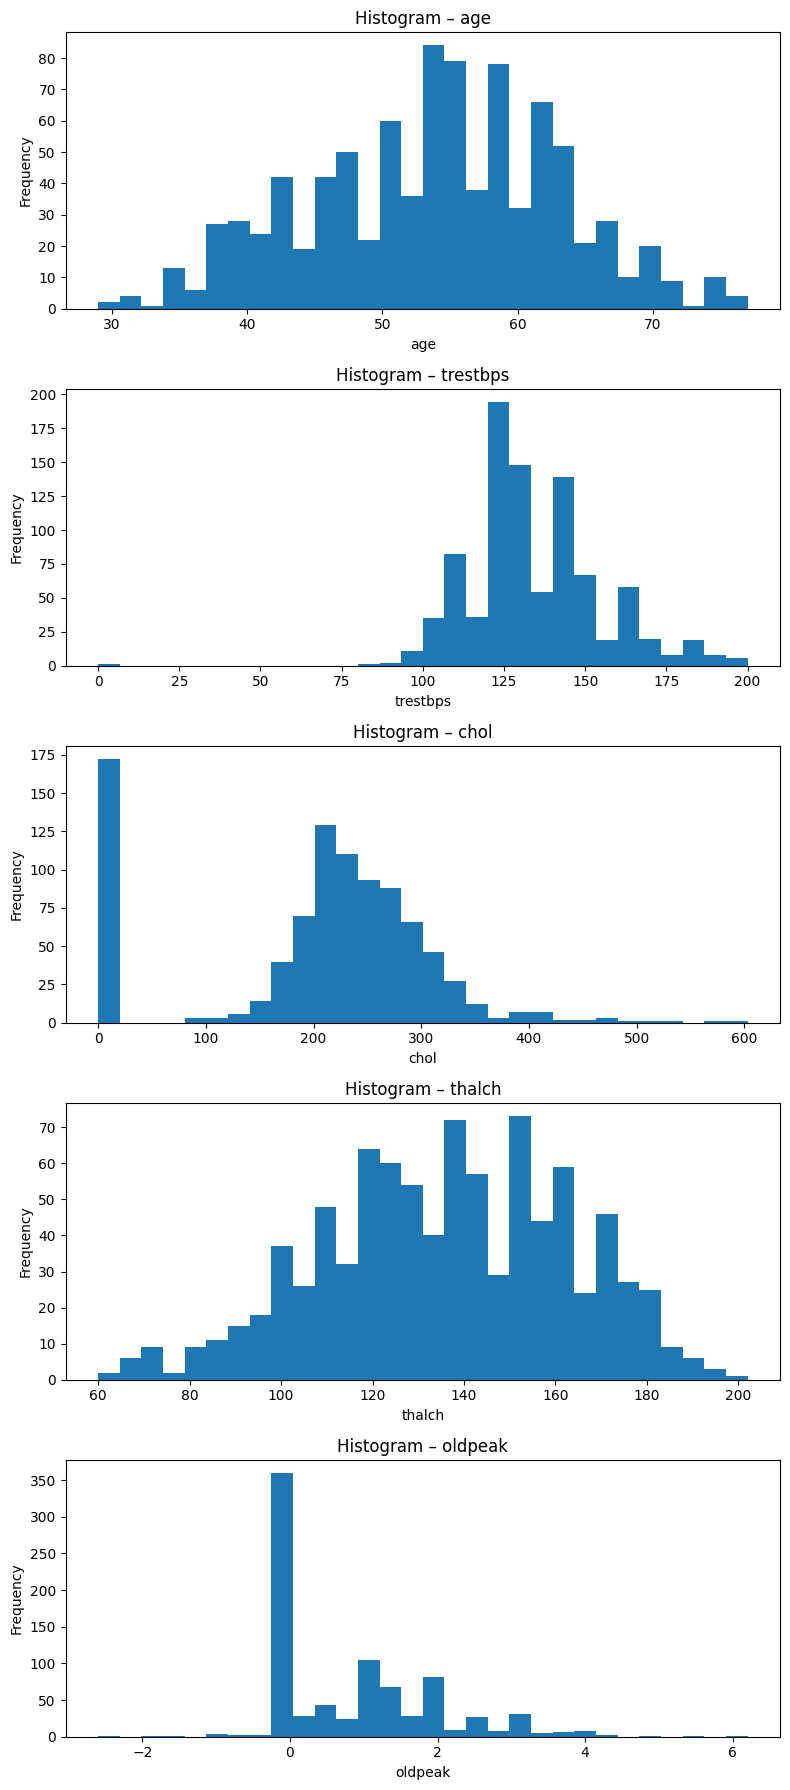

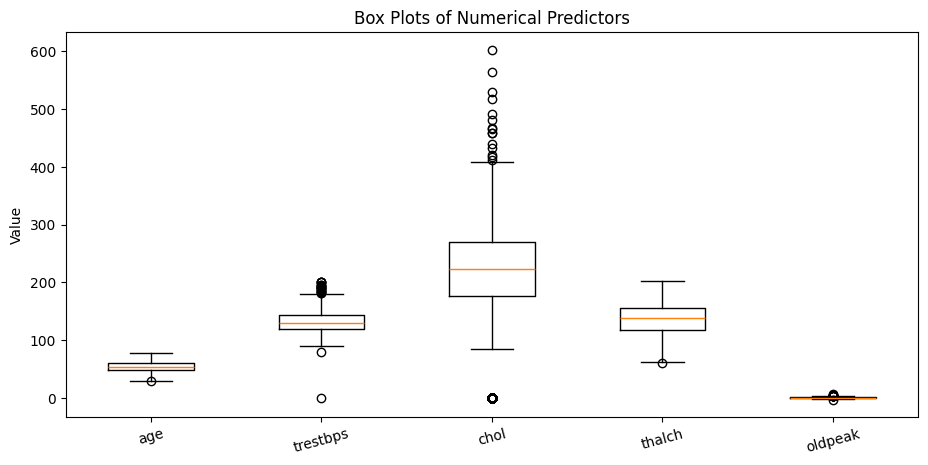

In [9]:
fig, axes = plt.subplots(len(numeric_predictors), 1, figsize=(8, 18))

for ax, col in zip(axes, numeric_predictors):
    ax.hist(df_clean[col].dropna(), bins=30)
    ax.set_title(f"Histogram – {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
plt.boxplot(
    [df_clean[col].dropna() for col in numeric_predictors],
    labels=numeric_predictors
)
plt.title("Box Plots of Numerical Predictors")
plt.ylabel("Value")
plt.xticks(rotation=15)
plt.show()


## 7. Target distribution

The target has five classes: 0, 1, 2, 3 and 4.

The data dictionary says these represent no heart disease and stages of heart disease respectively. The class distribution is important because the higher stages may have fewer observations than the lower classes.


,Count,Percentage
num,,
0,399,43.94
1,265,29.19
2,109,12.00
3,107,11.78
4,28,3.08


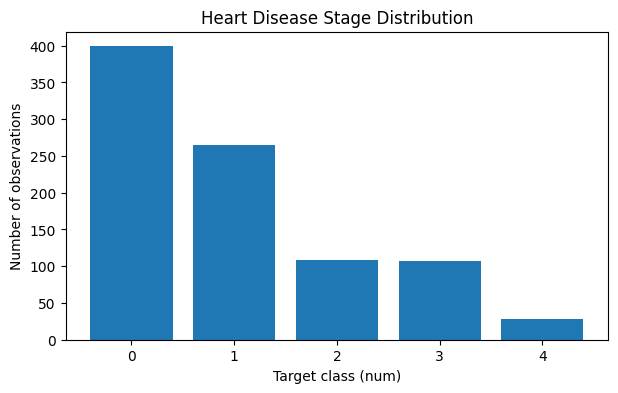

In [10]:
target_counts = df_clean["num"].value_counts().sort_index()
target_table = pd.DataFrame({
    "Count": target_counts,
    "Percentage": (target_counts / len(df_clean) * 100).round(2)
})

display(target_table)

plt.figure(figsize=(7, 4))
plt.bar(target_counts.index.astype(str), target_counts.values)
plt.title("Heart Disease Stage Distribution")
plt.xlabel("Target class (num)")
plt.ylabel("Number of observations")
plt.show()


## 8. Correlation matrix

A correlation matrix is useful for numerical variables. It shows linear relationships between the predictors and the target.

The categorical predictors are not included in this numerical correlation matrix because their text categories should not be treated as arbitrary numeric values.


,age,trestbps,chol,thalch,oldpeak,num
age,1.000,0.254,-0.100,-0.328,0.243,0.326
trestbps,0.254,1.000,0.117,-0.133,0.167,0.137
chol,-0.100,0.117,1.000,0.198,0.030,-0.239
thalch,-0.328,-0.133,0.198,1.000,-0.140,-0.323
oldpeak,0.243,0.167,0.030,-0.140,1.000,0.438
num,0.326,0.137,-0.239,-0.323,0.438,1.000


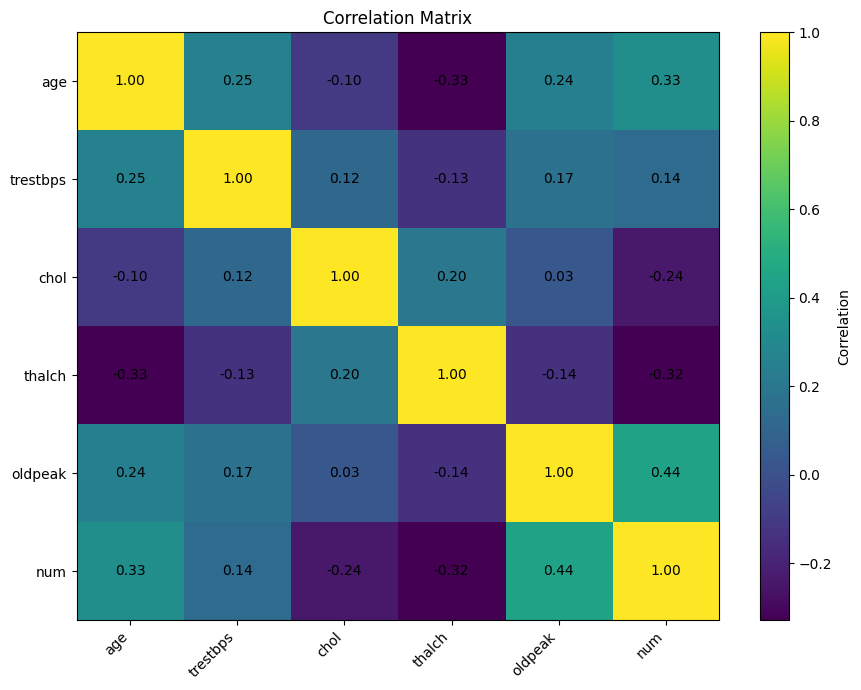

In [11]:
corr_cols = numeric_predictors + ["num"]
corr = df_clean[corr_cols].corr()

display(corr.round(3))

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 9. Feature engineering and preprocessing

The assignment says to perform feature engineering **if necessary**.

There are categorical variables in this dataset, so I use **One-Hot Encoding** for them. This avoids creating a false numerical order between categories.

For numerical variables:
- Missing `oldpeak` values are filled using the median.
- Decision Trees do **not require feature scaling**, so I do not scale the numerical predictors for the Decision Tree model.



In [12]:
target = "num"

X = df_clean.drop(columns=[target])
y = df_clean[target].astype(int)

categorical_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numeric_cols)


Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical columns: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']


## 10. Train-test split

I use an **80/20 train-test split**, which is also the example given in the assignment.

`stratify=y` is used so that the proportions of the five target classes remain similar in the training and test sets.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).sort_index().round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).sort_index().round(3))


Training set: (726, 12)
Testing set: (182, 12)

Training target distribution:
num
0    0.439
1    0.292
2    0.120
3    0.118
4    0.030
Name: proportion, dtype: float64

Testing target distribution:
num
0    0.440
1    0.291
2    0.121
3    0.115
4    0.033
Name: proportion, dtype: float64


## 11. Decision Tree preprocessing pipeline

The preprocessing pipeline:
1. Median-imputes numerical variables.
2. One-hot encodes categorical variables.

The preprocessing is fitted only on the training data through the pipeline. This helps avoid information leakage from the test set.


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_cols
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            categorical_cols
        )
    ]
)

base_tree = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

base_tree.fit(X_train, y_train)
y_pred_base = base_tree.predict(X_test)

print("Base Decision Tree trained successfully.")


Base Decision Tree trained successfully.


## 12. Base Decision Tree evaluation

Because the target contains five classes, I use **weighted averages** for precision, recall and F1-score. This accounts for the different number of observations in each class.

I also calculate multiclass ROC-AUC using a one-vs-rest approach where the model provides class probabilities.


In [15]:
def evaluate_tree(model, X_test, y_test, name):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (weighted)": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1 Score (weighted)": f1_score(y_test, pred, average="weighted", zero_division=0),
        "ROC-AUC (OvR weighted)": roc_auc_score(
            y_test, prob, multi_class="ovr", average="weighted"
        )
    }
    return result, pred, prob

base_result, y_pred_base, y_prob_base = evaluate_tree(
    base_tree, X_test, y_test, "Base Decision Tree"
)

display(pd.DataFrame([base_result]).round(4))

print("Classification report:")
print(classification_report(
    y_test, y_pred_base,
    zero_division=0
))


,Model,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted),ROC-AUC (OvR weighted)
0,Base Decision Tree,0.4615,0.4927,0.4615,0.4753,0.64


Classification report:
              precision    recall  f1-score   support

           0       0.75      0.66      0.70        80
           1       0.39      0.38      0.38        53
           2       0.13      0.18      0.15        22
           3       0.24      0.29      0.26        21
           4       0.20      0.17      0.18         6

    accuracy                           0.46       182
   macro avg       0.34      0.33      0.34       182
weighted avg       0.49      0.46      0.48       182



## 13. Confusion Matrix

The confusion matrix shows how observations from each heart-disease stage were classified.

The diagonal contains correct predictions, while the off-diagonal cells show which stages are being confused with each other.


,Predicted 0,Predicted 1,Predicted 2,Predicted 3,Predicted 4
Actual 0,53,16,4,7,0
Actual 1,9,20,12,9,3
Actual 2,5,10,4,3,0
Actual 3,3,4,7,6,1
Actual 4,1,1,3,0,1


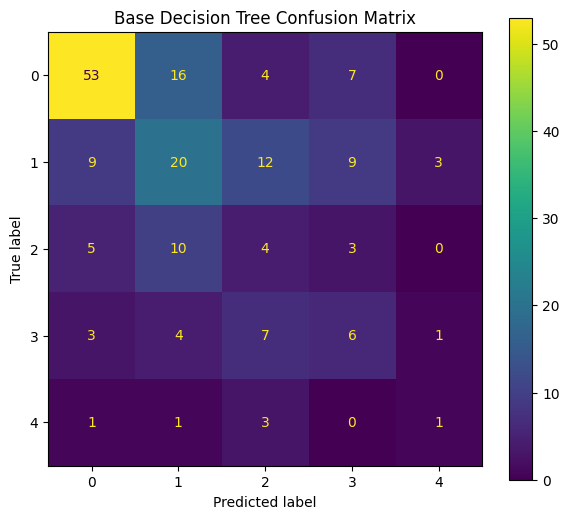

In [16]:
cm_base = confusion_matrix(y_test, y_pred_base, labels=[0,1,2,3,4])

display(pd.DataFrame(
    cm_base,
    index=["Actual 0","Actual 1","Actual 2","Actual 3","Actual 4"],
    columns=["Predicted 0","Predicted 1","Predicted 2","Predicted 3","Predicted 4"]
))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=cm_base,
    display_labels=[0,1,2,3,4]
).plot(values_format="d", ax=ax)
plt.title("Base Decision Tree Confusion Matrix")
plt.show()


## 14. Hyperparameter Tuning

The assignment specifically asks for experiments with:
- maximum depth
- minimum samples split
- criterion

I also include `min_samples_leaf`, because it can help control overly complex trees.

### Why these parameters matter

- `max_depth`: limits how deep the tree can grow. A very deep tree can overfit.
- `min_samples_split`: sets the minimum number of observations required to split a node.
- `min_samples_leaf`: requires a minimum number of observations in each final leaf.
- `criterion`: determines the impurity measure used to choose splits, such as Gini or entropy/log loss.


In [17]:
param_grid = {
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10],
    "classifier__criterion": ["gini", "entropy"]
}

grid_search = GridSearchCV(
    estimator=base_tree,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=5,
    n_jobs=-1,
    return_train_score=False
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation weighted F1-score:",
      round(grid_search.best_score_, 4))


Best parameters:
{'classifier__criterion': 'gini', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}

Best cross-validation weighted F1-score: 0.5338


## 15. Tuned Decision Tree Evaluation

The best hyperparameters were selected using only the training data through five-fold cross-validation. The test set is then used for the final evaluation.


In [18]:
best_tree = grid_search.best_estimator_

tuned_result, y_pred_tuned, y_prob_tuned = evaluate_tree(
    best_tree, X_test, y_test, "Tuned Decision Tree"
)

display(pd.DataFrame([tuned_result]).round(4))

print("Classification report:")
print(classification_report(
    y_test, y_pred_tuned,
    zero_division=0
))


,Model,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted),ROC-AUC (OvR weighted)
0,Tuned Decision Tree,0.522,0.4915,0.522,0.5019,0.7254


Classification report:
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        80
           1       0.44      0.60      0.51        53
           2       0.09      0.05      0.06        22
           3       0.24      0.24      0.24        21
           4       0.00      0.00      0.00         6

    accuracy                           0.52       182
   macro avg       0.30      0.32      0.31       182
weighted avg       0.49      0.52      0.50       182



## 16. Compare Base and Tuned Models

,Accuracy,Precision (weighted),Recall (weighted),F1 Score (weighted),ROC-AUC (OvR weighted)
Model,,,,,
Base Decision Tree,0.4615,0.4927,0.4615,0.4753,0.6400
Tuned Decision Tree,0.5220,0.4915,0.5220,0.5019,0.7254


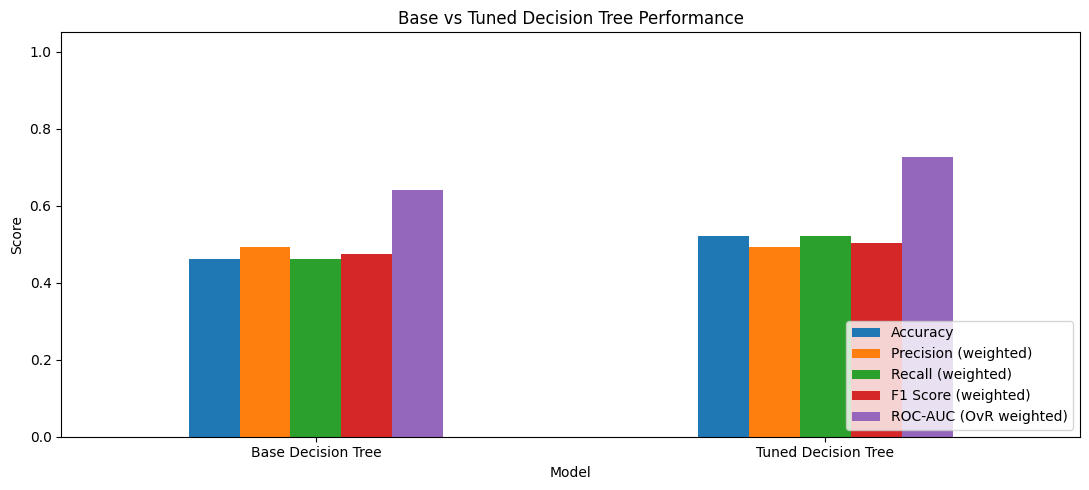

In [19]:
comparison = pd.DataFrame([
    base_result,
    tuned_result
]).set_index("Model")

display(comparison.round(4))

comparison.plot(
    kind="bar",
    figsize=(11, 5),
    ylim=(0, 1.05)
)
plt.title("Base vs Tuned Decision Tree Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 17. Visualize the Decision Tree

The assignment asks to visualize the tree structure so that the learned rules can be understood.

A fully grown tree can be very large, so I display a limited-depth view for readability. The actual tuned model is still used for evaluation.


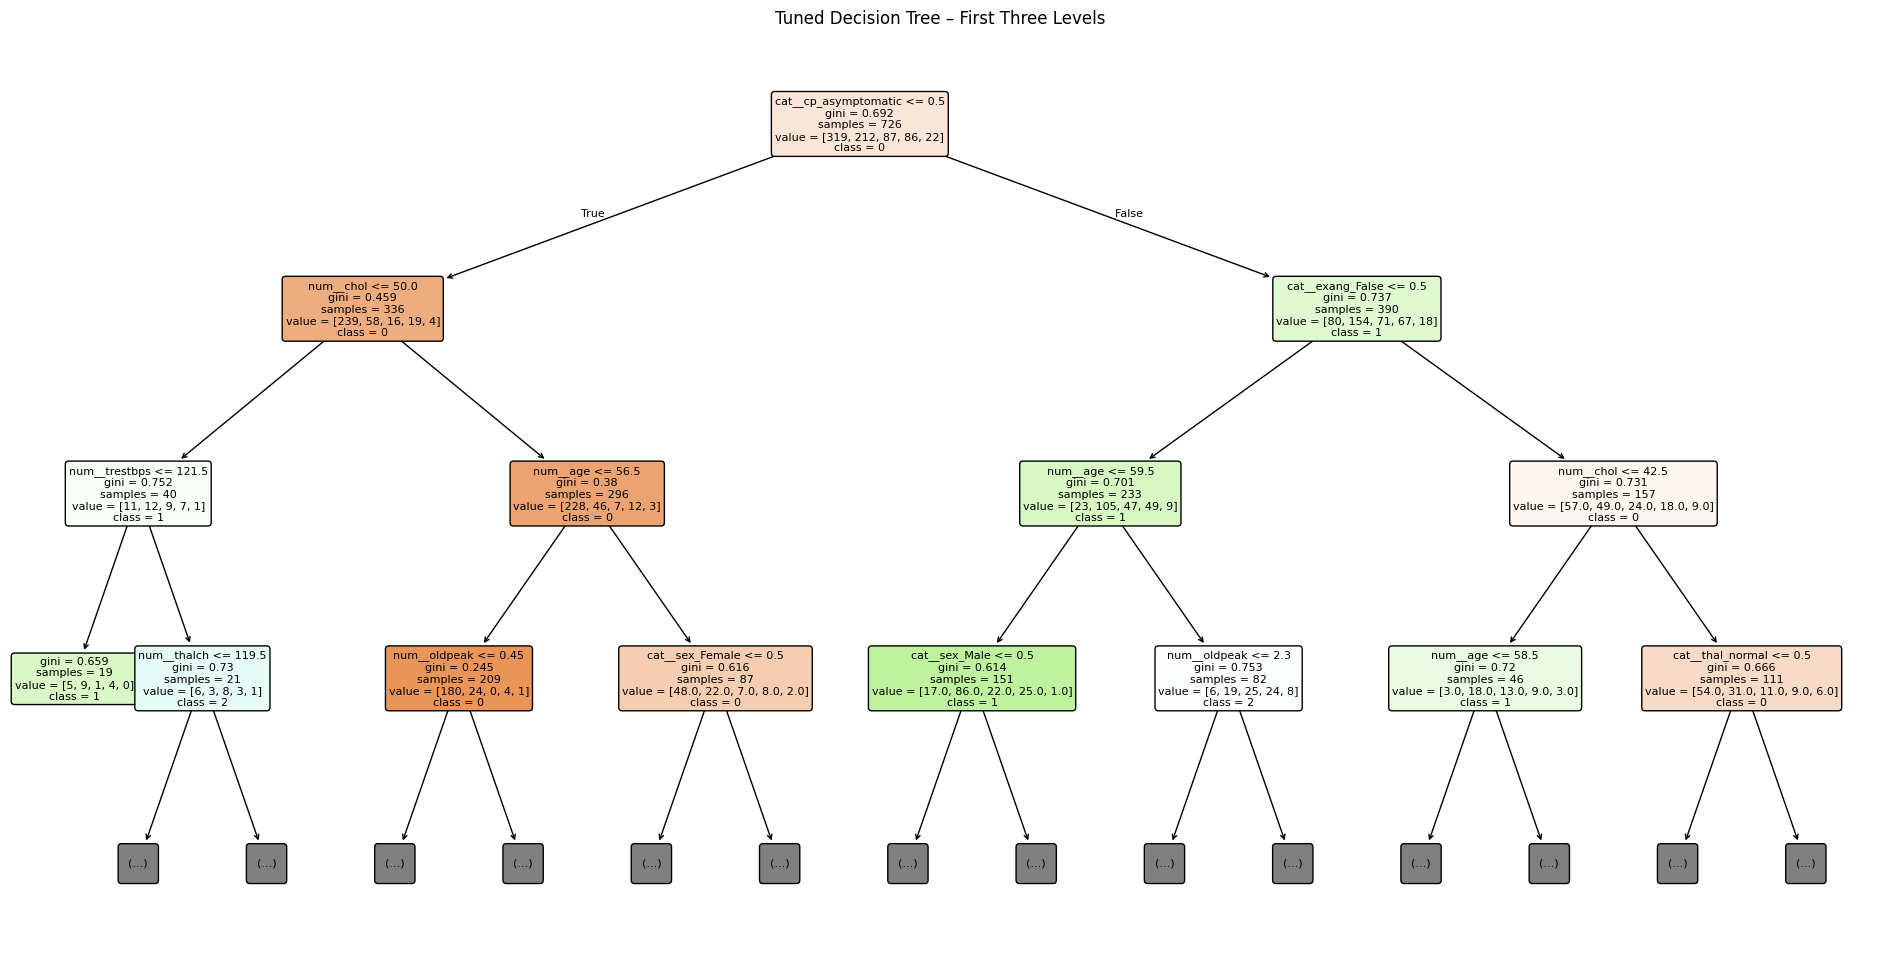

In [20]:
# Get the transformed feature names from the fitted preprocessing pipeline.
fitted_preprocessor = best_tree.named_steps["preprocessor"]
feature_names = fitted_preprocessor.get_feature_names_out()

tree_model = best_tree.named_steps["classifier"]

plt.figure(figsize=(24, 12))
plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title("Tuned Decision Tree – First Three Levels")
plt.show()


## 18. Feature Importance

Decision Trees provide `feature_importances_`, which measures the contribution of each transformed feature to reducing impurity in the tree.

Because categorical variables were one-hot encoded, one original categorical variable may appear as several encoded features.


Top 15 transformed features:


,Importance
cat__cp_asymptomatic,0.330509
num__chol,0.160919
num__age,0.112109
num__oldpeak,0.069242
num__trestbps,0.066857
cat__thal_normal,0.053582
cat__exang_False,0.051279
cat__slope_upsloping,0.040869
cat__sex_Female,0.031111
num__thalch,0.026929


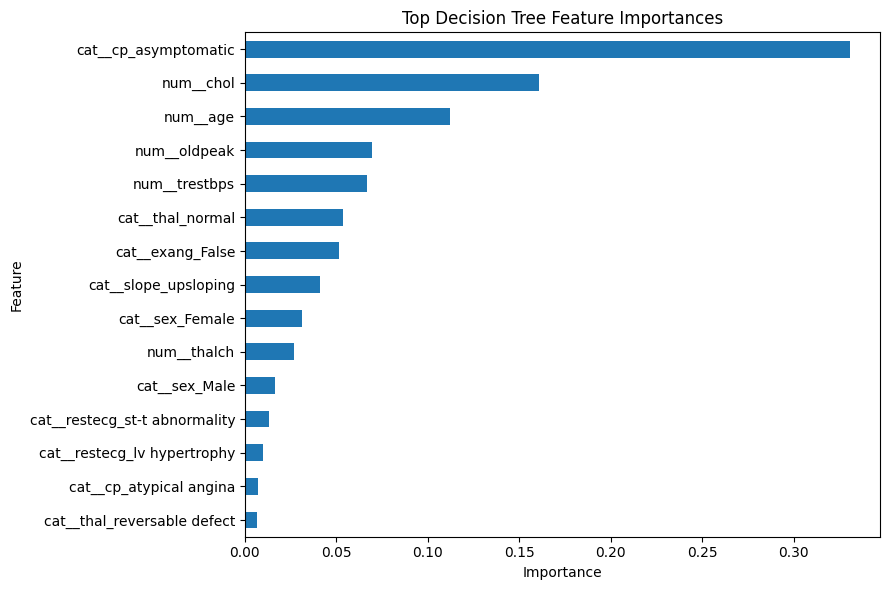

In [21]:
importance = pd.Series(
    tree_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("Top 15 transformed features:")
display(importance.head(15).to_frame("Importance"))

plt.figure(figsize=(9, 6))
importance.head(15).sort_values().plot(kind="barh")
plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 19. Training vs Test Performance

One of the main risks with Decision Trees is overfitting. A very deep tree can learn the training observations extremely closely.

I compare the training and test weighted F1-scores for the base and tuned models. A very large gap can be a sign of overfitting.


In [22]:
base_train_pred = base_tree.predict(X_train)
tuned_train_pred = best_tree.predict(X_train)

train_test_scores = pd.DataFrame({
    "Model": ["Base Tree", "Tuned Tree"],
    "Training F1 (weighted)": [
        f1_score(y_train, base_train_pred, average="weighted", zero_division=0),
        f1_score(y_train, tuned_train_pred, average="weighted", zero_division=0)
    ],
    "Testing F1 (weighted)": [
        f1_score(y_test, y_pred_base, average="weighted", zero_division=0),
        f1_score(y_test, y_pred_tuned, average="weighted", zero_division=0)
    ]
})

display(train_test_scores.round(4))


,Model,Training F1 (weighted),Testing F1 (weighted)
0,Base Tree,1.0000,0.4753
1,Tuned Tree,0.6444,0.5019


## 20. Analysis of the Results

The exact performance values are generated when the notebook is run. The main points I would use to interpret them are:

1. **Accuracy** shows the overall proportion of correctly classified patients.
2. **Precision** shows how reliable the predicted class labels are.
3. **Recall** shows how well the model identifies observations belonging to each stage.
4. **Weighted F1-score** provides a single summary that balances precision and recall while accounting for class size.
5. **ROC-AUC** gives a multiclass one-vs-rest measure of class discrimination.

Because the dataset is multiclass and the stage 4 class is much smaller than class 0, weighted metrics should be interpreted together with the classification report. A high weighted score can still hide weaker performance on a small class.

The confusion matrix is especially useful here because it shows which heart-disease stages the model confuses.


## 21. Strengths and Weaknesses of Decision Trees

### Strengths

- Easy to understand compared with many other machine-learning models.
- Can represent non-linear relationships.
- Does not require numerical feature scaling.
- Can work with both numerical and encoded categorical predictors.
- The tree structure can be visualized as decision rules.
- Feature importance can provide a useful first interpretation.

### Weaknesses

- A deep tree can overfit the training data.
- Small changes in the data can sometimes produce a different tree.
- A single tree may not generalize as well as ensemble methods.
- Feature importance from a tree should not be interpreted as causation.
- One-hot encoding can increase the number of input features when categorical variables have many categories.


# Interview Questions

## 1. What are some common hyperparameters of Decision Tree models, and how do they affect model performance?

### `max_depth`
Controls the maximum depth of the tree.

- A small value makes the tree simpler and can reduce overfitting.
- A very large value allows the tree to become more complex and can increase overfitting.

### `min_samples_split`
Controls the minimum number of observations required before a node can be split.

- Increasing it makes the tree more conservative.
- A larger value can reduce overfitting but may also underfit.

### `min_samples_leaf`
Controls the minimum number of observations that must remain in a leaf.

- Larger values make the tree smoother and less complex.
- Smaller values allow the tree to model more detailed patterns.

### `criterion`
Specifies the impurity measure used when choosing splits. Common choices include:
- `gini`
- `entropy`
- `log_loss`

Different criteria can result in different split decisions and therefore different tree structures.

### `max_features`
Controls how many features are considered when searching for a split.

Changing this can affect both the diversity of the splits and the model's complexity.

Overall, hyperparameters control the trade-off between a tree that is too simple and one that is too complex.


## 2. What is the difference between Label Encoding and One-Hot Encoding?

### Label Encoding

Label Encoding assigns a numerical value to each category.

For example:

- Male → 0
- Female → 1

It uses fewer columns, but for nominal categories the numbers can incorrectly suggest an order.

### One-Hot Encoding

One-Hot Encoding creates a separate binary column for each category.

For example, a chest-pain variable with three categories could become:

- `cp_typical_angina`
- `cp_atypical_angina`
- `cp_non_anginal`

Each row receives 0 or 1 in these columns.

The advantage is that it does not imply that one category is numerically greater than another. The disadvantage is that it can create many columns when a categorical variable has many unique categories.

### In this assignment

I used **One-Hot Encoding** for the categorical predictor variables because they are nominal categories and the dataset does not provide a meaningful numerical ordering for them.


# Final Conclusion

The analysis includes:
- Dataset loading
- Variable understanding
- Missing-value checking and imputation
- Inconsistency checking and correction of the `exang` entries
- IQR-based outlier analysis
- Histograms and box plots
- Correlation matrix
- Target/class distribution
- Categorical encoding
- 80/20 train-test split
- Base Decision Tree
- Accuracy, precision, recall, F1-score and multiclass ROC-AUC
- Confusion matrix
- Hyperparameter tuning
- Base vs tuned model comparison
- Decision-tree visualization
- Feature importance
- Training vs test performance
- Model analysis
- Interview-question answers

The final interpretation should be based on the metric values produced when the notebook is executed. In particular, the confusion matrix and class-specific classification report should be checked because the target classes are not equally represented.
